In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.gaussian import make_gaussian_plane_wave_round_aperture
from temgym_core.gaussian_taylor import (
    Lens,
    run_to_end,
)
from temgym_core.utils import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_for, evaluate_gaussians_jax_scan


In [2]:
jax.config.update("jax_enable_x64", True)
W = 100e-9

Nx = Ny = 512
dx = W/Nx
dy = W/Ny
input_grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
input_extent = input_grid.extent
coords = input_grid.coords
X, Y = coords[:, 0].reshape(input_grid.shape), coords[:, 1].reshape(input_grid.shape)

voltage = 100e3
wavelength = energy2wavelength(voltage)  # 200 keV
k0 = 2 * jnp.pi / wavelength


In [3]:
w0 = 1e-8  # Beam waist

rays_in = make_gaussian_plane_wave_round_aperture(
    voltage=voltage,
    aperture_radius=W / 2,
    waist_radius=w0,
    num_rays=1,
    normalization='unit',
)
rays_in = rays_in.to_vector()

M = -5
f = 0.5e-3
z1 = f * (1 - 1 / M)
z2 = f * (1 - M)
lens = Lens(focal_length=f, z=abs(z1))
output_grid = Detector(z=abs(z1) + abs(z2), pixel_size=(dx * 10, dy * 10), shape=(Nx, Ny))
output_extent = output_grid.extent
rays_out = run_to_end(rays_in, [lens, output_grid])


/home/dl277493/Microscope-Calibration/TemGymCore/src/temgym_core/utils.py:352: RuntimeWarning: invalid value encountered in sqrt
  radius * np.sqrt((ii + 0.5) / (nb_samples - 0.5 * (np_boundary + 1)))


1e-08


In [4]:
E_in = evaluate_gaussians_for(rays_out, input_grid)
E_gpu = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid)
E_scan = evaluate_gaussians_jax_scan(rays_out, input_grid)

assert jnp.allclose(E_in, E_gpu), "E_in and E_gpu are not the same"
assert jnp.allclose(E_in, E_scan), "E_in and E_scan are not the same"
assert jnp.allclose(E_gpu, E_scan), "E_gpu and E_scan are not the same"

(-5e-07, 4.980468749999999e-07, 5e-07, -4.980468749999999e-07)

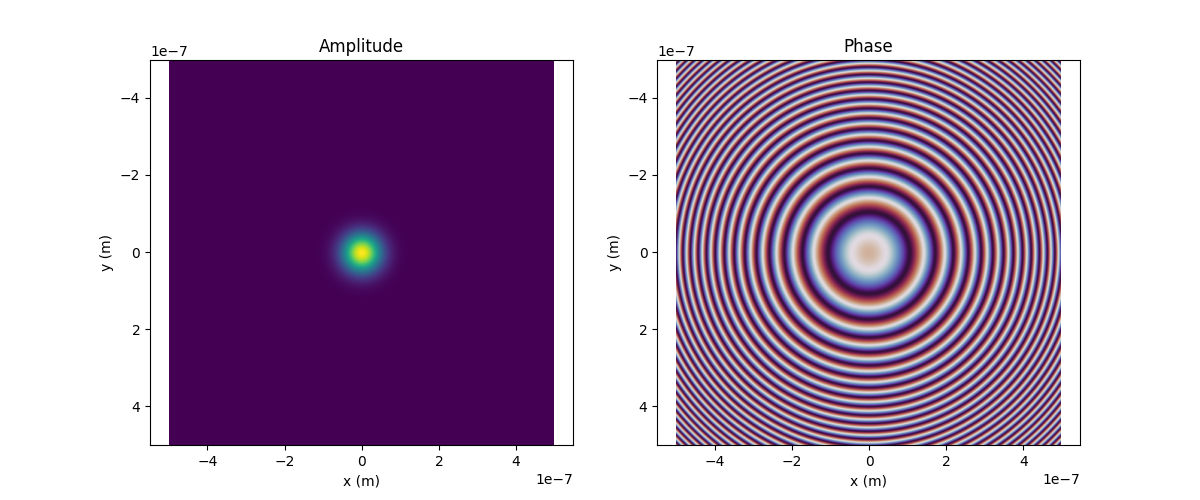

In [5]:
E_out = evaluate_gaussians_gpu_kernel_wrapper(rays_out, output_grid)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Phase of gaussian beam
axs[0].imshow(np.abs(E_out), extent=output_extent)
axs[0].set_title('Amplitude')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].axis('equal')

axs[1].imshow(np.angle(E_out), extent=output_extent, cmap='twilight', vmin=-jnp.pi, vmax=jnp.pi)
axs[1].set_title('Phase')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('y (m)')
axs[1].axis('equal')